In [1]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam

In [2]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TRAIN_PATH = "smartvision_dataset/classification/train"
VAL_PATH = "smartvision_dataset/classification/val"

train_datagen = ImageDataGenerator(rescale=1./255)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical'
)

Found 1750 images belonging to 25 classes.
Found 375 images belonging to 25 classes.


In [3]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

2026-04-18 19:36:50.702470: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2026-04-18 19:36:50.702515: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-04-18 19:36:50.702527: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-04-18 19:36:50.702571: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-18 19:36:50.702593: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


58889256/58889256 [==============================] - 9s 0us/step


In [4]:
for layer in base_model.layers:
    layer.trainable = False

In [5]:
model = Sequential([
    base_model,
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])

In [6]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)

Epoch 1/10


2026-04-18 19:37:12.430987: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.
2026-04-18 19:37:12.449901: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:961] model_pruner failed: INVALID_ARGUMENT: Graph does not contain terminal node Adam/AssignAddVariableOp.


55/55 [==============================] - 26s 466ms/step - loss: 3.7522 - accuracy: 0.1326 - val_loss: 2.2980 - val_accuracy: 0.4027
Epoch 2/10
55/55 [==============================] - 25s 454ms/step - loss: 2.5126 - accuracy: 0.3577 - val_loss: 1.8740 - val_accuracy: 0.5067
Epoch 3/10
55/55 [==============================] - 26s 467ms/step - loss: 1.9182 - accuracy: 0.5091 - val_loss: 1.5886 - val_accuracy: 0.5813
Epoch 4/10
55/55 [==============================] - 25s 451ms/step - loss: 1.4854 - accuracy: 0.6091 - val_loss: 1.4223 - val_accuracy: 0.6160
Epoch 5/10
55/55 [==============================] - 25s 453ms/step - loss: 1.1654 - accuracy: 0.6966 - val_loss: 1.2953 - val_accuracy: 0.6320
Epoch 6/10
55/55 [==============================] - 27s 497ms/step - loss: 0.9250 - accuracy: 0.7617 - val_loss: 1.2246 - val_accuracy: 0.6880
Epoch 7/10
55/55 [==============================] - 36s 654ms/step - loss: 0.8065 - accuracy: 0.8017 - val_loss: 1.1790 - val_accuracy: 0.6907
Epoch 8/10

In [10]:
model.save("models/vgg16_model.h5")
print("Model Saved ✅")

Model Saved ✅


/Users/sabari/Documents/DS/GUVI/SmartVision-AI/venv/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


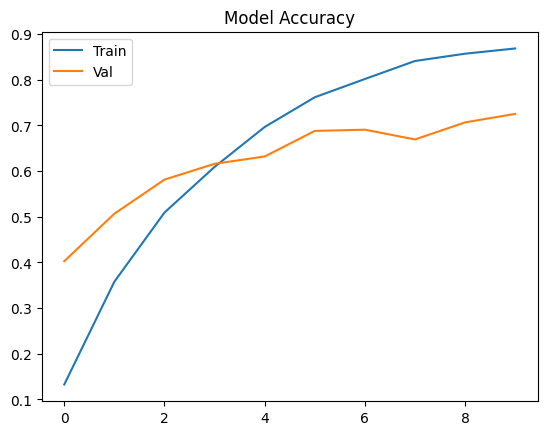

In [11]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Model Accuracy")
plt.legend(["Train","Val"])
plt.show()